In [6]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from experiments.scripts.run_experiments import run_experiment
from experiments.scripts.experiment_utils import generate_experiments

In [8]:
base_config = {
    # Experiment
    "experiment": "toroidal_topo_AE_normalized",
    "random_seed": 42,
    "logging": True,

    # Dataset
    "dataset_name": "t2_synthetic",
    "batch_size": 64,
    "rotation": "random",
    "translation": None,
    "n_times": 10000,
    "embedding_dim": 10,
    "major_radius": 2,
    "minor_radius": 1,
    "noise_var": 0.001,
    "geodesic_distortion_amp": 0.0,

    # Model
    'model_type': 'ToroidalAE',
    'latent_dim': 4,
    'manifold_dim': 2,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [100,100,100],
    'decoder_widths': [100,100,100],
    'use_angle_constraint': False,
    'activation': 'softplus',
    'normalize': True,

    # Optimizer
    "learning_rate": 0.001,

    # Trainer
    'verbose': False,
    'num_epochs': 100,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': True,
    'dim_topo_loss': 2,  # Max feature dimension topological loss
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': 0.0,  # Weight for KL loss
    'gamma': 1.0,  # Weight for topological loss

    # Curvature computation
    "plot_curvatures": False,
    "compute_emp_curv": False,
    "compute_true_curv": False,
    "compute_learned_curv": False,
    "compute_rec_curv": False,
    "quadric_dim": 1,
    "n_plot_points": 10000,
    "n_points_emp_curv": 1000,
    "n_points_pullback_curv": 1000, 
    "k": 110,
    "smoothing": False,

    # Persistent homology
    "persistent_homology": False,
    "n_points_pers_hom": 1000,
    "scale": False,
    "homology_dimensions": [0, 1]
}

param_grid = {
    'dim_topo_loss': [0,0,1,2],
    "gamma": [0.0,1.0,1.0,1.0],
}

all_configs = generate_experiments(base_config, param_grid)


Running exp00_toroidal_topo_AE_normalized. 
Description: dim_topo_loss=0, gamma=0.0
--------------------------------------------------------------------------------------


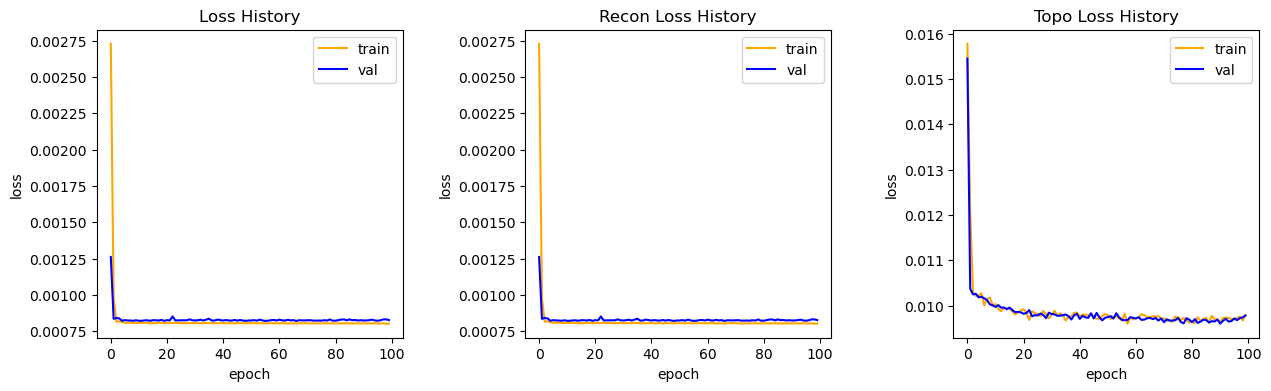

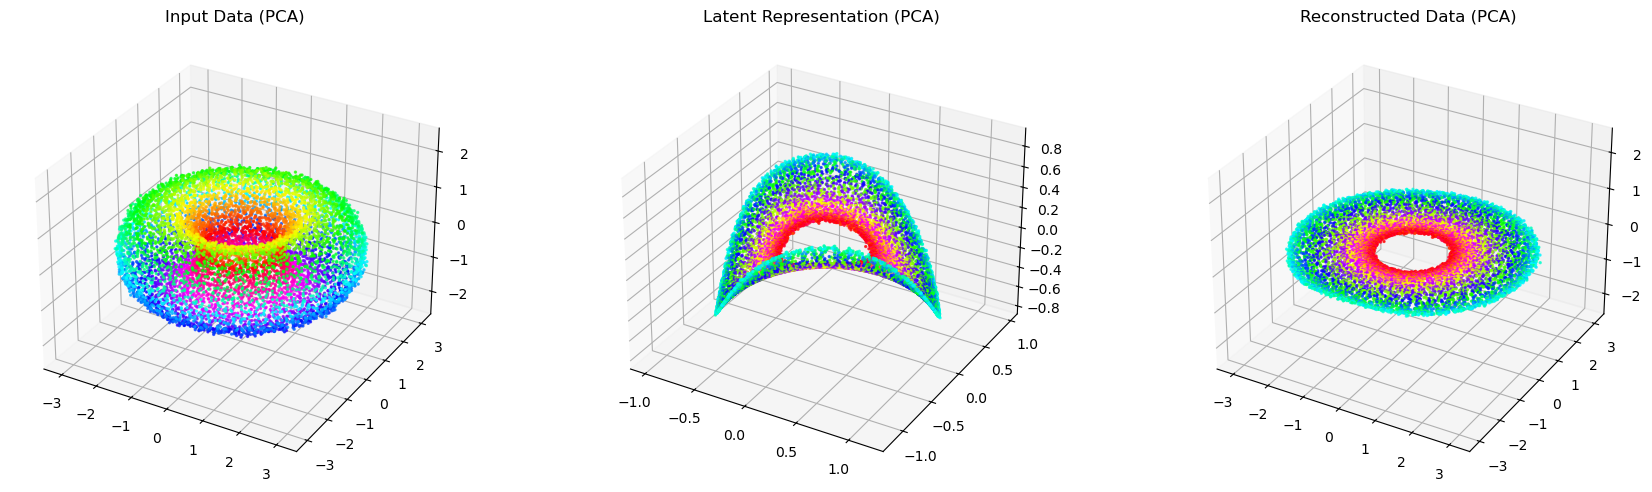

Execution time exp00_toroidal_topo_AE_normalized: 110.5113 seconds

Running exp01_toroidal_topo_AE_normalized. 
Description: dim_topo_loss=0, gamma=1.0
--------------------------------------------------------------------------------------


<Figure size 640x480 with 0 Axes>

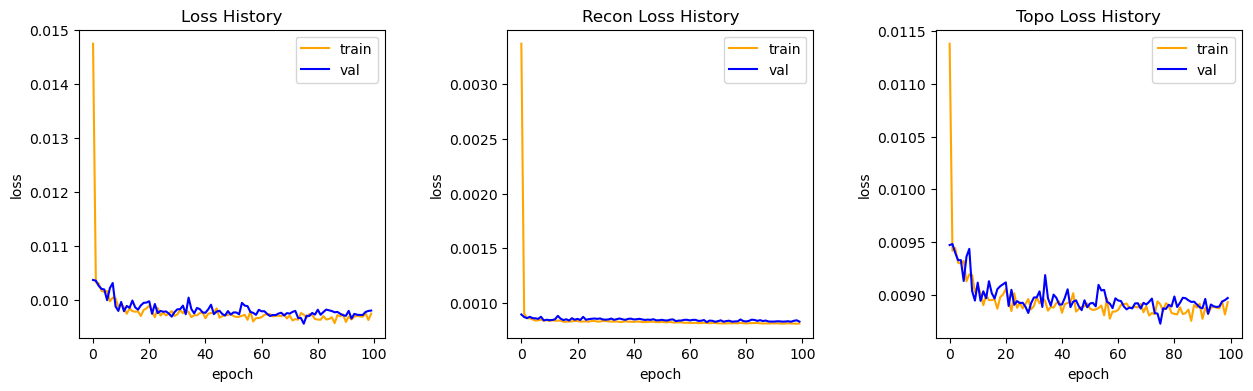

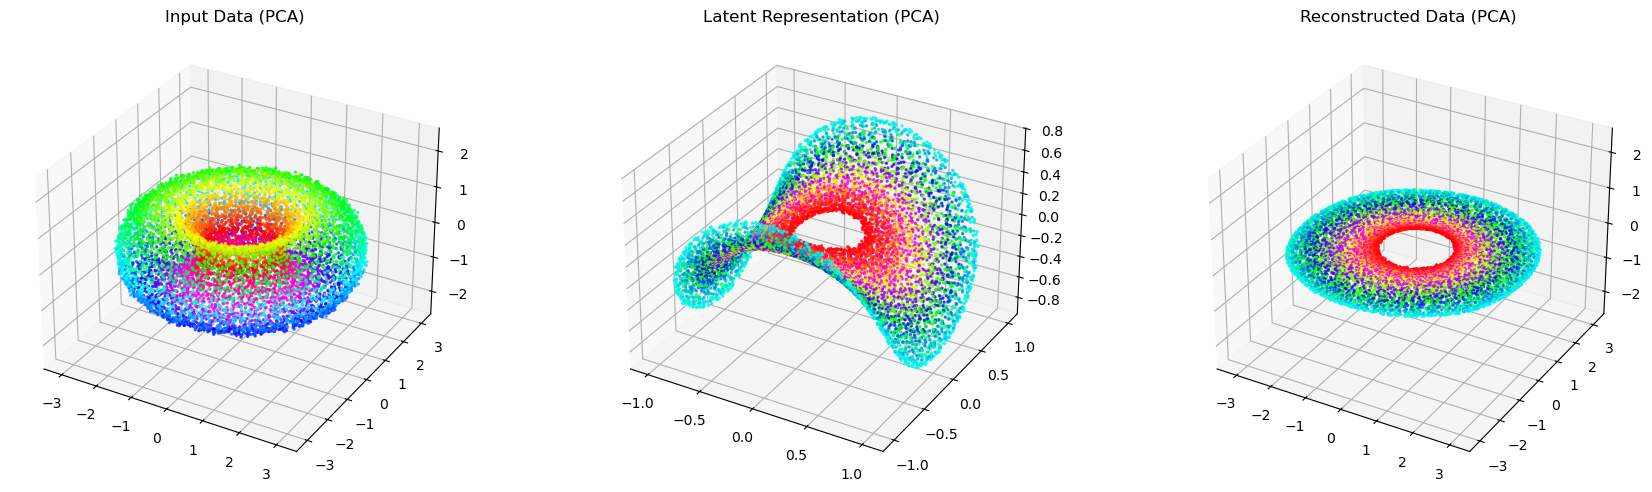

Execution time exp01_toroidal_topo_AE_normalized: 215.8939 seconds

Running exp02_toroidal_topo_AE_normalized. 
Description: dim_topo_loss=1, gamma=1.0
--------------------------------------------------------------------------------------


<Figure size 640x480 with 0 Axes>

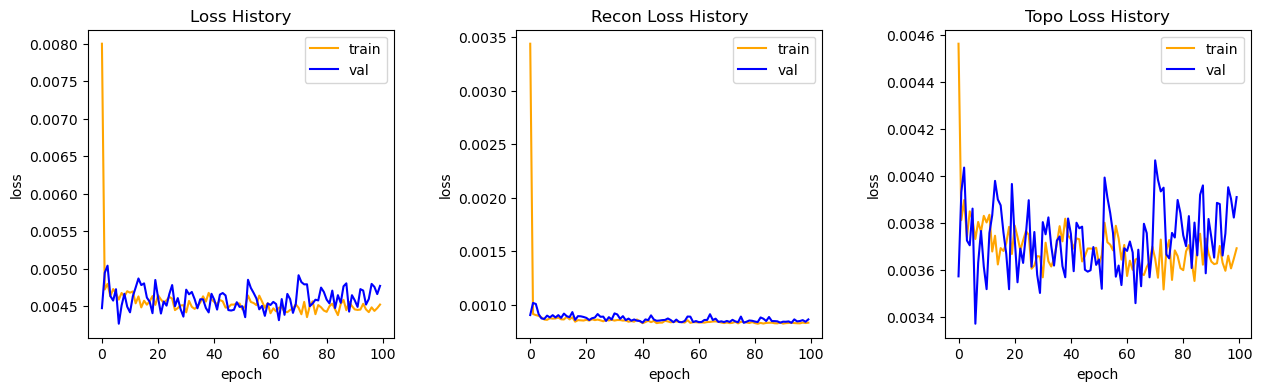

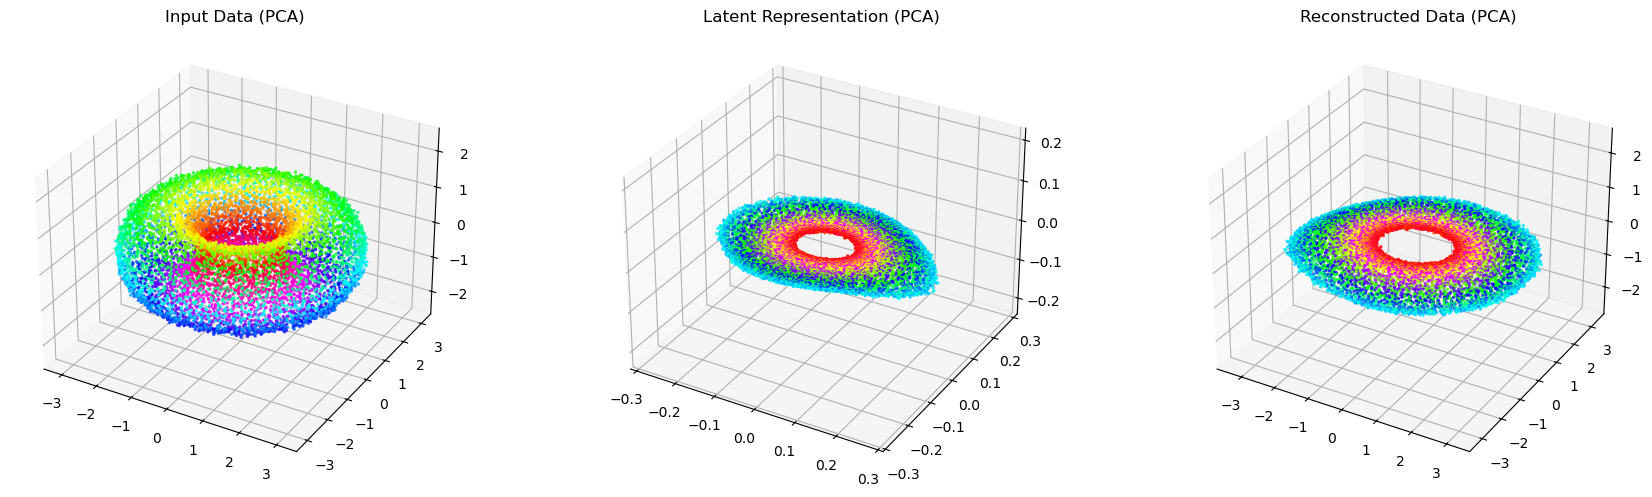

Execution time exp02_toroidal_topo_AE_normalized: 366.0443 seconds

Running exp03_toroidal_topo_AE_normalized. 
Description: dim_topo_loss=2, gamma=1.0
--------------------------------------------------------------------------------------


<Figure size 640x480 with 0 Axes>

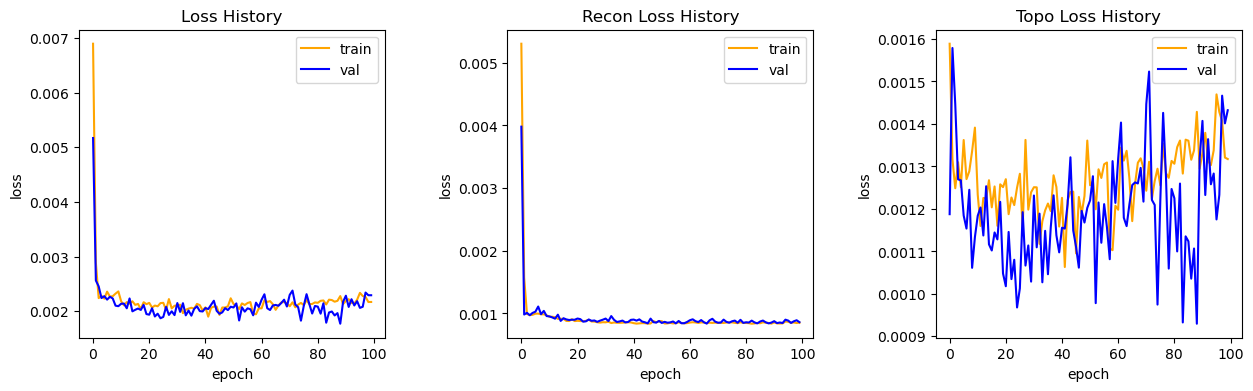

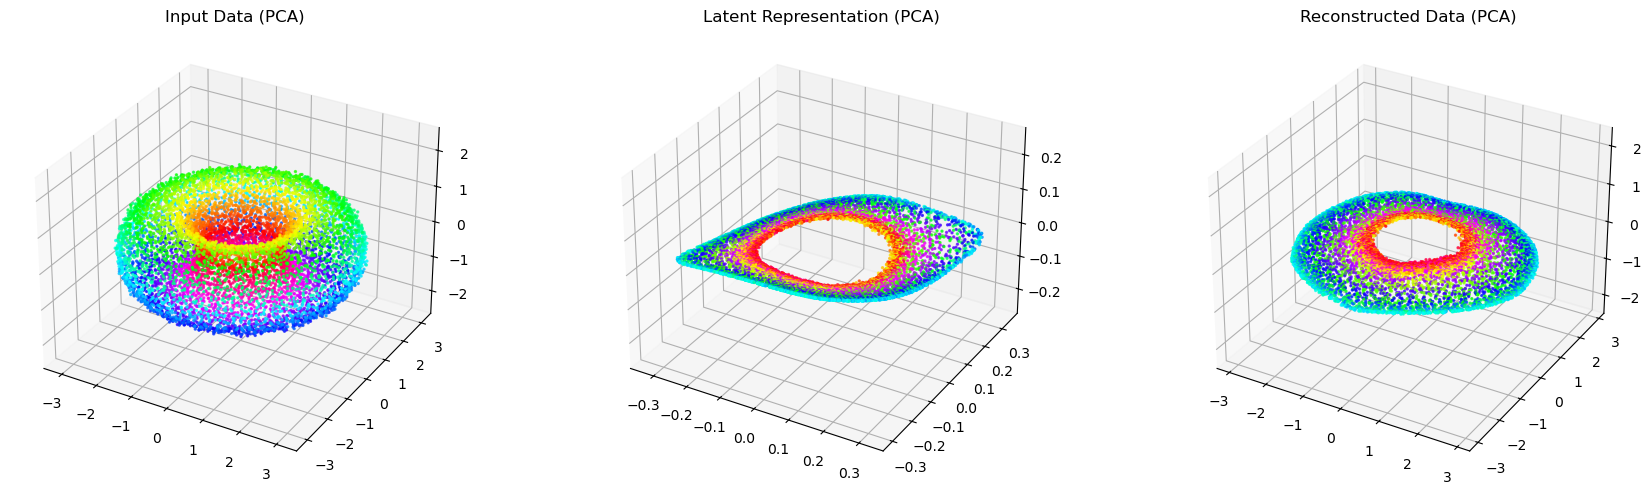

Execution time exp03_toroidal_topo_AE_normalized: 821.1927 seconds


<Figure size 640x480 with 0 Axes>

In [9]:
run_experiment(all_configs=all_configs)
